输出目录: results_placebo/
Step 1: 加载数据
数据维度: (59146, 113)
时间范围: 2019-07-01 13:25:00 ~ 2021-06-30 23:55:00
正样本数: 2565  (4.34%)

full_with_coordination特征数: 102
Step 2: 划分数据集
训练集: 41,816 样本 | 正样本: 1401 (3.35%)
测试集: 3,759 样本  | 正样本: 396 (10.53%)
事件前: 28,052 样本  | 正样本: 903 (3.22%)

随机基准 PR-AUC ≈ 0.1053（正例比率）
模型配置完成: ['LightGBM', 'XGBoost', 'Logistic']
Step 4: 真实模型训练（基准）

  LightGBM:
    测试集 PR-AUC:  0.5487
    事件前 PR-AUC:  0.7969
    事件前误报率:   10.14%

  XGBoost:
    测试集 PR-AUC:  0.4895
    事件前 PR-AUC:  0.8928
    事件前误报率:   8.00%

  Logistic:
    测试集 PR-AUC:  0.2995
    事件前 PR-AUC:  0.1496
    事件前误报率:   24.83%
Step 5: 标签打乱测试（50次）
  进度: 10/50...
  进度: 20/50...
  进度: 30/50...
  进度: 40/50...
  进度: 50/50...

  标签打乱测试完成
  随机基准（正例比率）: 0.1053

  LightGBM:
    打乱后均值: 0.0829 ± 0.0096
    真实模型:   0.5487
    信号提升:   +0.4657 (+561.5%)
  XGBoost:
    打乱后均值: 0.0791 ± 0.0078
    真实模型:   0.4895
    信号提升:   +0.4104 (+518.8%)
  Logistic:
    打乱后均值: 0.1414 ± 0.0607
    真实模型:   0.2995
    信号提升:   +0.1581 (+111.8%)

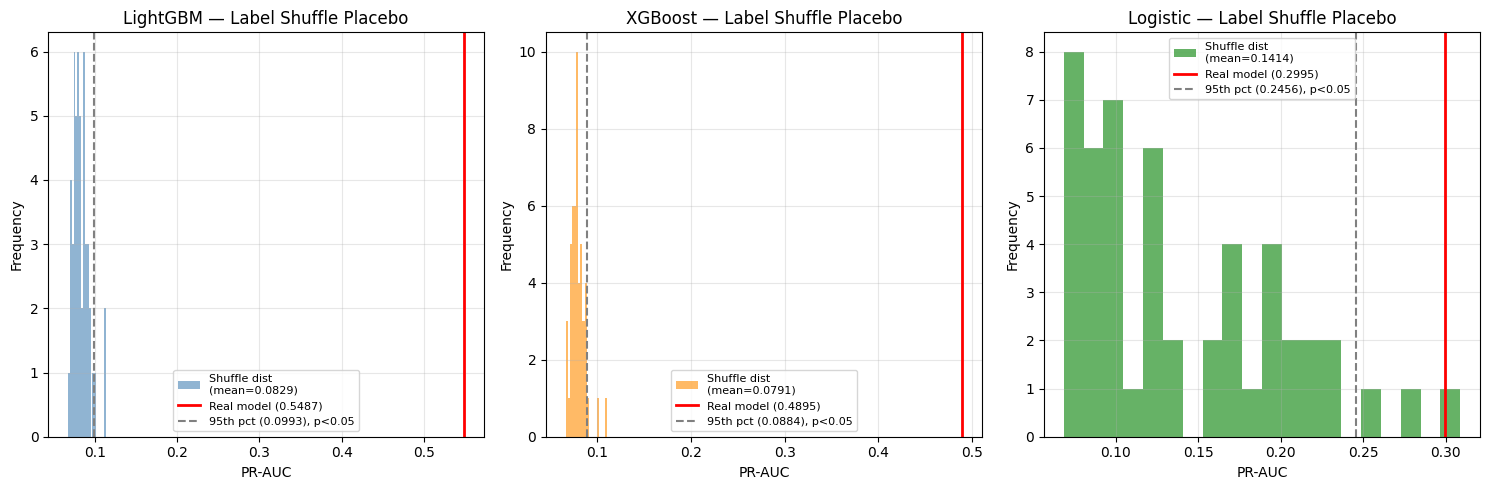

✓ 保存: results_placebo/placebo_shuffle.png


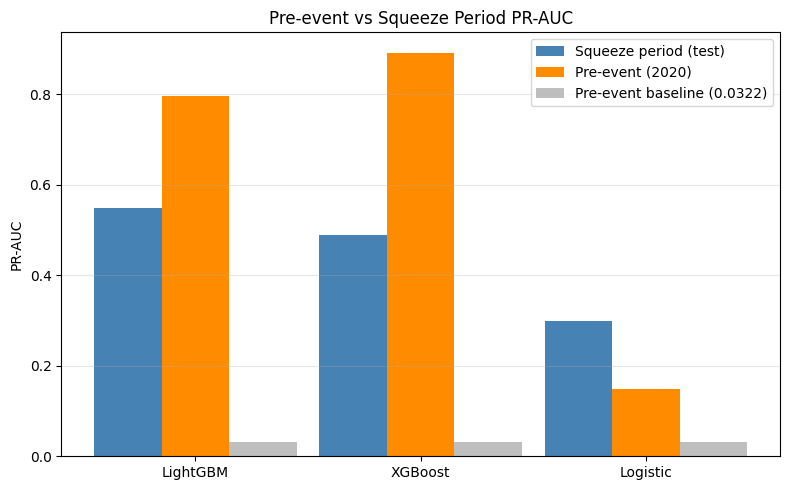

✓ 保存: results_placebo/placebo_pre_event.png

✓ 所有安慰剂测试完成


In [3]:
"""
Placebo Test
============
两种安慰剂测试：
1. Label Shuffle: 打乱训练集标签50次，看PR-AUC是否接近随机基准
2. Pre-event Window: 用2020年全年作为测试集，看误报率

模型：LightGBM（主力）、XGBoost、Logistic
特征：full_with_coordination（主要结果对应的特征组合）
"""

import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

# ── 配置 ─────────────────────────────────────────────────────────────────────
DATA_FILE   = 'data/merged_data_scaled_CLEAN.parquet'
GROUPS_FILE = 'data/feature_groups_CLEAN.json'
TARGET      = 'EWS_15min'
N_SHUFFLE   = 50       # 标签打乱次数
RANDOM_SEED = 42

# 时间切割（与主模型一致）
TRAIN_END   = '2021-01-25 23:59:59'
VAL_START   = '2021-01-26 00:00:00'
VAL_END     = '2021-01-27 23:59:59'
TEST_START  = '2021-01-28 00:00:00'
TEST_END    = '2021-02-28 23:59:59'

# 事件前窗口
PRE_START   = '2020-01-01 00:00:00'
PRE_END     = '2020-12-31 23:59:59'

LEAKAGE_FEATURES = [
    'is_episode_t', 'is_luld', 'is_anomaly',
    'is_price_spike', 'is_volume_surge',
    'thread_concentration', 'is_official_halt',
]

OUT_DIR = 'results_placebo'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'输出目录: {OUT_DIR}/')

# ── 1. 加载数据 ───────────────────────────────────────────────────────────────
print('='*65)
print('Step 1: 加载数据')
print('='*65)

df = pd.read_parquet(DATA_FILE)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

with open(GROUPS_FILE, 'r', encoding='utf-8') as f:
    feature_groups = json.load(f)

print(f'数据维度: {df.shape}')
print(f'时间范围: {df["timestamp"].min()} ~ {df["timestamp"].max()}')
print(f'正样本数: {int(df[TARGET].sum())}  ({df[TARGET].mean()*100:.2f}%)')

# 官方halt滞后特征加入market组
halt_lag = [c for c in ['is_official_halt_lag1', 'is_official_halt_lag2']
            if c in df.columns]
if halt_lag:
    feature_groups['market'] = list(feature_groups.get('market', [])) + halt_lag

# full_with_coordination特征
FULL_GROUPS = ['market', 'cascade', 'network', 'temporal', 'text',
               'burstiness', 'user_overlap', 'text_duplication']

all_features = []
for g in FULL_GROUPS:
    all_features.extend(feature_groups.get(g, []))
all_features = [f for f in dict.fromkeys(all_features) if f in df.columns]
all_features = [f for f in all_features if f not in LEAKAGE_FEATURES]

print(f'\nfull_with_coordination特征数: {len(all_features)}')

# ── 2. 划分数据集 ─────────────────────────────────────────────────────────────
print('='*65)
print('Step 2: 划分数据集')
print('='*65)

train_mask = df['timestamp'] <= TRAIN_END
test_mask  = (df['timestamp'] >= TEST_START) & (df['timestamp'] <= TEST_END)
pre_mask   = (df['timestamp'] >= PRE_START)  & (df['timestamp'] <= PRE_END)

X_train = df.loc[train_mask, all_features].fillna(0)
y_train = df.loc[train_mask, TARGET]
X_test  = df.loc[test_mask,  all_features].fillna(0)
y_test  = df.loc[test_mask,  TARGET]
X_pre   = df.loc[pre_mask,   all_features].fillna(0)
y_pre   = df.loc[pre_mask,   TARGET]

spw = (y_train == 0).sum() / y_train.sum()

print(f'训练集: {len(X_train):,} 样本 | 正样本: {int(y_train.sum())} ({y_train.mean()*100:.2f}%)')
print(f'测试集: {len(X_test):,} 样本  | 正样本: {int(y_test.sum())} ({y_test.mean()*100:.2f}%)')
print(f'事件前: {len(X_pre):,} 样本  | 正样本: {int(y_pre.sum())} ({y_pre.mean()*100:.2f}%)')
print(f'\n随机基准 PR-AUC ≈ {y_test.mean():.4f}（正例比率）')

# ── 3. 定义三个模型 ───────────────────────────────────────────────────────────
MODELS = {
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, random_state=RANDOM_SEED,
        n_jobs=-1, verbose=-1
    ),
    'XGBoost': XGBClassifier(
        max_depth=6, learning_rate=0.05, n_estimators=300,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, scale_pos_weight=spw, random_state=RANDOM_SEED,
        n_jobs=-1, eval_metric='aucpr', verbosity=0
    ),
    'Logistic': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1
    ),
}

print('模型配置完成:', list(MODELS.keys()))

# ── 4. 真实模型训练（基准）────────────────────────────────────────────────────
print('='*65)
print('Step 4: 真实模型训练（基准）')
print('='*65)

real_results = {}

for name, model in MODELS.items():
    model.fit(X_train, y_train)

    # 测试集（squeeze期）
    y_prob_test = model.predict_proba(X_test)[:, 1]
    pr_auc_test = average_precision_score(y_test, y_prob_test)
    roc_auc_test = roc_auc_score(y_test, y_prob_test)

    # 事件前窗口
    y_prob_pre = model.predict_proba(X_pre)[:, 1]
    pr_auc_pre = average_precision_score(y_pre, y_prob_pre) if y_pre.sum() > 0 else np.nan
    false_alert_rate = (y_prob_pre >= 0.5).mean()  # 误报率

    real_results[name] = {
        'pr_auc_test':      pr_auc_test,
        'roc_auc_test':     roc_auc_test,
        'pr_auc_pre':       pr_auc_pre,
        'false_alert_rate': false_alert_rate,
    }

    print(f'\n  {name}:')
    print(f'    测试集 PR-AUC:  {pr_auc_test:.4f}')
    print(f'    事件前 PR-AUC:  {pr_auc_pre:.4f}')
    print(f'    事件前误报率:   {false_alert_rate*100:.2f}%')

# ── 5. 标签打乱测试（Label Shuffle Placebo）───────────────────────────────────
print('='*65)
print(f'Step 5: 标签打乱测试（{N_SHUFFLE}次）')
print('='*65)

shuffle_results = {name: [] for name in MODELS}
rng = np.random.RandomState(RANDOM_SEED)

for i in range(N_SHUFFLE):
    if (i+1) % 10 == 0:
        print(f'  进度: {i+1}/{N_SHUFFLE}...')

    # 打乱训练集标签
    y_shuffled = y_train.sample(frac=1, random_state=rng.randint(0, 99999)).values

    for name, model in MODELS.items():
        # 重新初始化同参数模型
        m = model.__class__(**model.get_params())
        m.fit(X_train, y_shuffled)
        y_prob = m.predict_proba(X_test)[:, 1]
        pr_auc = average_precision_score(y_test, y_prob)
        shuffle_results[name].append(pr_auc)

print('\n  标签打乱测试完成')
print(f'  随机基准（正例比率）: {y_test.mean():.4f}')
print()
for name in MODELS:
    arr = shuffle_results[name]
    print(f'  {name}:')
    print(f'    打乱后均值: {np.mean(arr):.4f} ± {np.std(arr):.4f}')
    print(f'    真实模型:   {real_results[name]["pr_auc_test"]:.4f}')
    lift = real_results[name]['pr_auc_test'] - np.mean(arr)
    print(f'    信号提升:   {lift:+.4f} ({lift/np.mean(arr)*100:+.1f}%)')

# ── 6. 汇总结果表 ─────────────────────────────────────────────────────────────
print('='*65)
print('Step 6: 汇总结果')
print('='*65)

rows = []
for name in MODELS:
    arr = shuffle_results[name]
    rows.append({
        'model':                   name,
        'real_pr_auc':             real_results[name]['pr_auc_test'],
        'real_roc_auc':            real_results[name]['roc_auc_test'],
        'shuffle_mean_pr_auc':     np.mean(arr),
        'shuffle_std_pr_auc':      np.std(arr),
        'shuffle_max_pr_auc':      np.max(arr),
        'random_baseline':         y_test.mean(),
        'signal_lift':             real_results[name]['pr_auc_test'] - np.mean(arr),
        'pre_event_pr_auc':        real_results[name]['pr_auc_pre'],
        'pre_event_false_alert':   real_results[name]['false_alert_rate'],
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

summary.to_csv(f'{OUT_DIR}/placebo_summary.csv', index=False)
print(f'\n✓ 保存: {OUT_DIR}/placebo_summary.csv')

# ── 7. 可视化 ─────────────────────────────────────────────────────────────────
print('Step 7: 可视化')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'LightGBM': 'steelblue', 'XGBoost': 'darkorange', 'Logistic': 'green'}

for idx, name in enumerate(MODELS):
    ax = axes[idx]
    arr = shuffle_results[name]

    # 打乱分布直方图
    ax.hist(arr, bins=20, color=colors[name], alpha=0.6,
            label=f'Shuffle dist\n(mean={np.mean(arr):.4f})')

    # 真实模型PR-AUC
    ax.axvline(real_results[name]['pr_auc_test'], color='red', lw=2,
               linestyle='-', label=f'Real model ({real_results[name]["pr_auc_test"]:.4f})')

    # 95th percentile（p<0.05显著性边界）
    p95 = np.percentile(arr, 95)
    ax.axvline(p95, color='gray', lw=1.5,
               linestyle='--', label=f'95th pct ({p95:.4f}), p<0.05')

    ax.set_title(f'{name} — Label Shuffle Placebo')
    ax.set_xlabel('PR-AUC')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/placebo_shuffle.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ 保存: {OUT_DIR}/placebo_shuffle.png')

# 事件前 vs 事件中对比图
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(MODELS))
w = 0.3
names = list(MODELS.keys())

bars1 = ax.bar(x - w, [real_results[n]['pr_auc_test'] for n in names],
               width=w, label='Squeeze period (test)', color='steelblue')
bars2 = ax.bar(x,     [real_results[n]['pr_auc_pre']  for n in names],
               width=w, label='Pre-event (2020)', color='darkorange')
bars3 = ax.bar(x + w, [y_pre.mean()] * len(names),
               width=w, label=f'Pre-event baseline ({y_pre.mean():.4f})', color='gray', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('PR-AUC')
ax.set_title('Pre-event vs Squeeze Period PR-AUC')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/placebo_pre_event.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ 保存: {OUT_DIR}/placebo_pre_event.png')

print('\n✓ 所有安慰剂测试完成')